REASONS

Customer-Initiated Reasons
High Fees
Better Options
Relocation
Poor Service
Account Consolidation
Security Concern
🔹 Bank-Initiated (RBI-Based)
Inactivity / Dormant Account
KYC Non-Compliance
Suspicious Activity
Terms Violation
Risk Profile Change

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
df = pd.read_csv("churn_prediction.csv")
df.head()

,customer_id,vintage,age,gender,dependents,occupation,city,customer_nw_category,branch_code,current_balance,...,average_monthly_balance_prevQ,average_monthly_balance_prevQ2,current_month_credit,previous_month_credit,current_month_debit,previous_month_debit,current_month_balance,previous_month_balance,churn,last_transaction
0,1,2101,66,Male,0.0,self_employed,187.0,2,755,1458.71,...,1458.71,1449.07,0.20,0.20,0.20,0.20,1458.71,1458.71,0,2019-05-21
1,2,2348,35,Male,0.0,self_employed,NaN,2,3214,5390.37,...,7799.26,12419.41,0.56,0.56,5486.27,100.56,6496.78,8787.61,0,2019-11-01
2,4,2194,31,Male,0.0,salaried,146.0,2,41,3913.16,...,4910.17,2815.94,0.61,0.61,6046.73,259.23,5006.28,5070.14,0,NaT
3,5,2329,90,NaN,NaN,self_employed,1020.0,2,582,2291.91,...,2084.54,1006.54,0.47,0.47,0.47,2143.33,2291.91,1669.79,1,2019-08-06
4,6,1579,42,Male,2.0,self_employed,1494.0,3,388,927.72,...,1643.31,1871.12,0.33,714.61,588.62,1538.06,1157.15,1677.16,1,2019-11-03


In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28382 entries, 0 to 28381
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     28382 non-null  int64  
 1   vintage                         28382 non-null  int64  
 2   age                             28382 non-null  int64  
 3   gender                          27857 non-null  object 
 4   dependents                      25919 non-null  float64
 5   occupation                      28302 non-null  object 
 6   city                            27579 non-null  float64
 7   customer_nw_category            28382 non-null  int64  
 8   branch_code                     28382 non-null  int64  
 9   current_balance                 28382 non-null  float64
 10  previous_month_end_balance      28382 non-null  float64
 11  average_monthly_balance_prevQ   28382 non-null  float64
 12  average_monthly_balance_prevQ2  

,0
customer_id,0
vintage,0
age,0
gender,525
dependents,2463
occupation,80
city,803
customer_nw_category,0
branch_code,0
current_balance,0


In [ ]:
df['gender'] = df['gender'].fillna('Unknown')
df['dependents'] = df['dependents'].fillna(0)
df['occupation'] = df['occupation'].fillna('Unknown')
df['city'] = df['city'].fillna(df['city'].median())

In [ ]:
df['last_transaction'] = pd.to_datetime(df['last_transaction'])
df.drop_duplicates(inplace=True)

In [ ]:
# Days inactive
df['Days_Inactive'] = (pd.Timestamp('today') - df['last_transaction']).dt.days

# Dormant (RBI rule)
df['Dormant'] = df['Days_Inactive'] > 730   # 2 years

# Balance change
df['Balance_Change'] = df['current_balance'] - df['previous_month_balance']

# Transaction change
df['Debit_Change'] = df['current_month_debit'] - df['previous_month_debit']

In [ ]:
#core
def assign_reason(row):

    # RBI Dormant
    if row['Days_Inactive'] > 730:
        return 'Inactive Account (RBI)'

    # Financial issues
    elif row['Balance_Change'] < -5000:
        return 'High Fees / Low Balance'

    # Switching banks
    elif row['Debit_Change'] < -2000:
        return 'Better Bank Options'

    # Low usage
    elif row['current_month_debit'] < 100:
        return 'Account Not Needed'

    # Suspicious activity
    elif row['current_month_credit'] > 1000000:
        return 'Security / Fraud Concern'

    else:
        return 'Other'

In [ ]:
df['Closure_Reason'] = df.apply(assign_reason, axis=1)

# Only churned customers should have reasons
df.loc[df['churn'] == 0, 'Closure_Reason'] = 'Active'

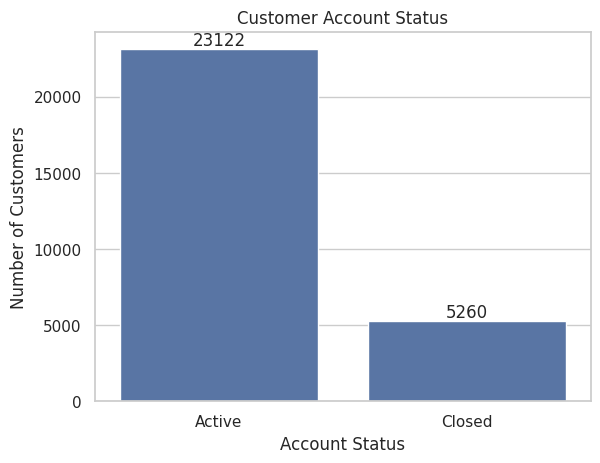

In [ ]:
df['churn_label'] = df['churn'].map({0: 'Active', 1: 'Closed'})

ax = sns.countplot(x='churn_label', data=df)

# Add values on top
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.title("Customer Account Status")
plt.xlabel("Account Status")
plt.ylabel("Number of Customers")
plt.show()

/tmp/ipykernel_913/1432459727.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reasons.values, y=reasons.index, palette=colors)


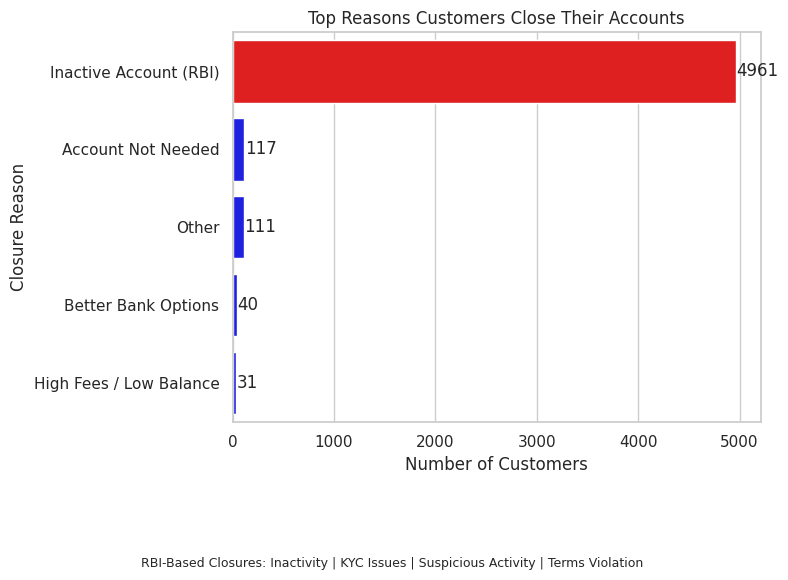

In [ ]:
reasons = df[df['churn'] == 1]['Closure_Reason'].value_counts().head(10)

plt.figure(figsize=(8,5))

ax = sns.barplot(x=reasons.values, y=reasons.index)

# Add values on bars
for i, v in enumerate(reasons.values):
    ax.text(v + 5, i, str(v), va='center')

plt.title("Top Reasons Customers Close Their Accounts")
plt.xlabel("Number of Customers")
plt.ylabel("Closure Reason")
colors = ['red' if 'RBI' in r else 'blue' for r in reasons.index]

sns.barplot(x=reasons.values, y=reasons.index, palette=colors)
# Add RBI explanation (fixed position)
plt.figtext(
    0.5, -0.15,
    "RBI-Based Closures: Inactivity | KYC Issues | Suspicious Activity | Terms Violation",
    ha="center",
    fontsize=9
)

plt.tight_layout()
plt.show()

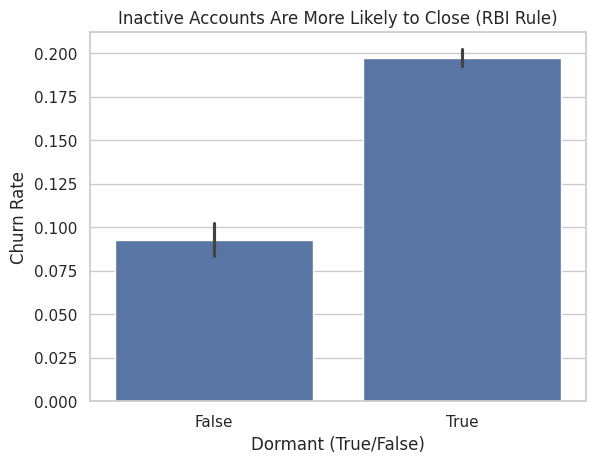

Text(0.5, -0.05, 'Dormant accounts have higher closure rates, supporting RBI guidelines')

<Figure size 640x480 with 0 Axes>

In [ ]:
sns.barplot(x='Dormant', y='churn', data=df)
plt.title("Inactive Accounts Are More Likely to Close (RBI Rule)")
plt.xlabel("Dormant (True/False)")
plt.ylabel("Churn Rate")
plt.show()

plt.figtext(
    0.5, -0.05,
"Dormant accounts have higher closure rates, supporting RBI guidelines",
    ha="center",
    fontsize=9
)

“Customers with lower balances are more likely to leave.”

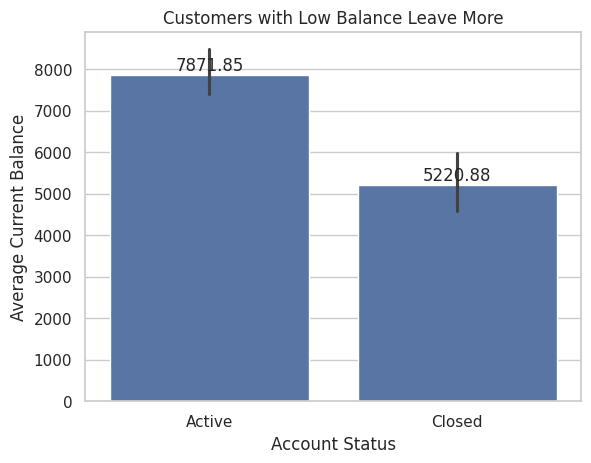

In [ ]:
df['churn_label'] = df['churn'].map({0: 'Active', 1: 'Closed'})

ax = sns.barplot(x='churn_label', y='current_balance', data=df)

plt.title("Customers with Low Balance Leave More")
plt.xlabel("Account Status")
plt.ylabel("Average Current Balance")

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom'
    )

plt.show()

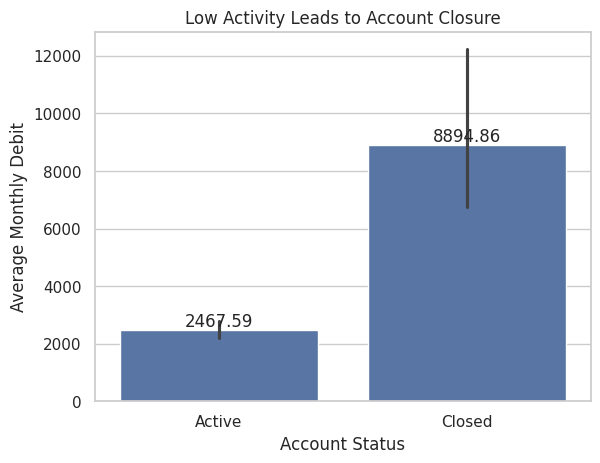

In [ ]:
ax = sns.barplot(x='churn_label', y='current_month_debit', data=df)

plt.title("Low Activity Leads to Account Closure")
plt.xlabel("Account Status")
plt.ylabel("Average Monthly Debit")

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center', va='bottom'
    )


In [ ]:
#“Accounts are closed either due to RBI rules or by customer choice”
def closure_type(reason):

    if reason == 'Inactive Account (RBI)' or reason == 'Security / Fraud Concern':
        return 'RBI Closure'

    elif reason in ['High Fees / Low Balance', 'Better Bank Options', 'Account Not Needed']:
        return 'Customer Closure'

    else:
        return 'Other'

df['Closure_Type'] = df['Closure_Reason'].apply(closure_type)

In [ ]:
#only for Closed accounts
closed = df[df['churn'] == 1]

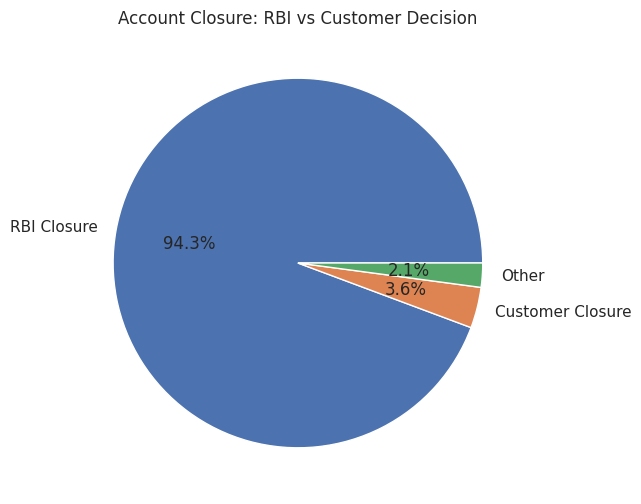

Text(0.5, -0.05, 'Others category includes customers with the following reasons:\n- Customer relocated\n- Customer unhappy with service (no complaint data)\n- KYC not updated / not available\n- Account consolidation\n- Random behavior patterns\n\nAlso includes cases with signals but no clear classification:\n- KYC status\n- Fraud flags\n- Customer complaints\n- Exact closure reason\n\nThese customers either do not match defined rules or only match weak/inconclusive signals.')

<Figure size 640x480 with 0 Axes>

In [ ]:
counts = closed['Closure_Type'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("Account Closure: RBI vs Customer Decision")
plt.show()


plt.figtext(
    0.5, -0.05,
    "Others category includes customers with the following reasons:\n"
    "- Customer relocated\n"
    "- Customer unhappy with service (no complaint data)\n"
    "- KYC not updated / not available\n"
    "- Account consolidation\n"
    "- Random behavior patterns\n\n"
    "Also includes cases with signals but no clear classification:\n"
    "- KYC status\n"
    "- Fraud flags\n"
    "- Customer complaints\n"
    "- Exact closure reason\n\n"
    "These customers either do not match defined rules or only match weak/inconclusive signals.",
    fontsize=9
)